In [2]:
import glob
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd


In [3]:
for x in os.listdir('./data'):
    print(x)

20260216_153455
r1
20260216_041416
20260216_143615
20260214_193635
20260216_014521
20260216_035937
20260216_130708
20260214_195402
20260214_190719


In [4]:
def fetch_data(data_dir):
    files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not files:
        print(f"No CSV files found in {data_dir}")
        return

    # Combine all CSVs into one dataframe
    all_data = pd.concat([pd.read_csv(f) for f in files])
    return all_data

import matplotlib.pyplot as plt

def plot_node_performance_1(summary, node_id):
    """
    Plots performance metrics comparing Standard DDP vs Bucket View 
    for a specific node_id across varying parameter counts.
    """
    # 1. Filter and split data
    node_df = summary[summary['node_id'] == node_id]
    no_gb = node_df[node_df['grad_bucket'] == 0].sort_values('num_params')
    with_gb = node_df[node_df['grad_bucket'] == 1].sort_values('num_params')

    # 2. Define metrics to plot
    plot_map = {
        "fwd_time": "Forward Pass Time",
        "bwd_time": "Backward Pass (Sync) Time",
        "opt_time": "Optimizer Step Time",
        "total_time": "Total Completion Time"
    }

    # 3. Initialize Grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (metric, title) in zip(axes, plot_map.items()):
        # Plot both series
        ax.plot(no_gb['num_params'], no_gb[metric], 'o-', label='Standard DDP ($gb=0$)')
        ax.plot(with_gb['num_params'], with_gb[metric], 's--', label='Bucket View ($gb=1$)')

        # Formatting
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'{title} (Node {node_id})', fontsize=12)
        ax.set_xlabel('Number of Parameters')
        ax.set_ylabel('Time (s)')
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

def process_ddp_results(data_dirs, metrics=None):
    """
    Fetches data from multiple directories, combines them, 
    and calculates mean performance metrics.
    """
    if metrics is None:
        metrics = ["fwd_time", "bwd_time", "opt_time", "total_time"]

    # 1. Fetch and Combine
    # Assumes fetch_data is a pre-defined function that returns a DataFrame
    all_dfs = [fetch_data(d) for d in data_dirs]
    combined_df = pd.concat(all_dfs, axis=0, ignore_index=True)
    
    # 2. Sort for consistent plotting later
    combined_df = combined_df.sort_values(by="num_params")
    
    # 3. Aggregate to Summary
    # Grouping by node and configuration to get the average timing per metric
    summary = (
        combined_df.groupby(["node_id", "num_params", "grad_bucket"])[metrics]
        .mean()
        .reset_index()
    )
    
    return combined_df, summary

import pandas as pd
import matplotlib.pyplot as plt

def plot_improvement_percentage(summary, node_id):
    """
    Plots the percentage improvement of Bucket View (gb=1) over Standard DDP (gb=0)
    across 4 subplots for a specific node_id.
    """
    # 1. Filter and Pivot
    df = summary[summary['node_id'] == node_id].copy()
    metrics = ["fwd_time", "bwd_time", "opt_time", "total_time"]
    pivoted = df.pivot(index='num_params', columns='grad_bucket', values=metrics)

    # 2. Map metrics to readable titles
    plot_map = {
        "fwd_time": "Forward Pass Improvement",
        "bwd_time": "Backward Pass (Sync) Improvement",
        "opt_time": "Optimizer Step Improvement",
        "total_time": "Total Completion Improvement"
    }

    # 3. Create 2x2 Grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, (metric, title) in enumerate(plot_map.items()):
        ax = axes[i]
        
        # Calculate % Improvement: ((Base - Improved) / Base) * 100
        base = pivoted[metric][0]
        improved = pivoted[metric][1]
        pct_improvement = ((base - improved) / base) * 100

        # Plot as Bar
        pct_improvement.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black', alpha=0.8)

        # Formatting
        ax.set_title(f"{title} (Node {node_id})", fontsize=13)
        ax.set_ylabel("Improvement (%)")
        ax.set_xlabel("Number of Parameters")
        ax.axhline(0, color='red', linewidth=1, linestyle='--') # Red line at 0 for "No Change"
        ax.grid(axis='y', linestyle='-', alpha=0.2)
        
        # Make x-labels readable
        ax.set_xticklabels(pct_improvement.index, rotation=45)

    plt.tight_layout()
    plt.show()


# No GDR

In [4]:
all_data, summary = process_ddp_results(['./data/20260214_193635/', './data/20260214_195402/'])
summary.head()

,node_id,num_params,grad_bucket,fwd_time,bwd_time,opt_time,total_time
0,1,2,0,0.001109,0.002582,0.000464,0.004155
1,1,2,1,0.000976,0.002361,0.000400,0.003736
2,1,4,0,0.001083,0.002579,0.000447,0.004109
3,1,4,1,0.001078,0.002407,0.000447,0.003932
4,1,8,0,0.001128,0.002599,0.000470,0.004197


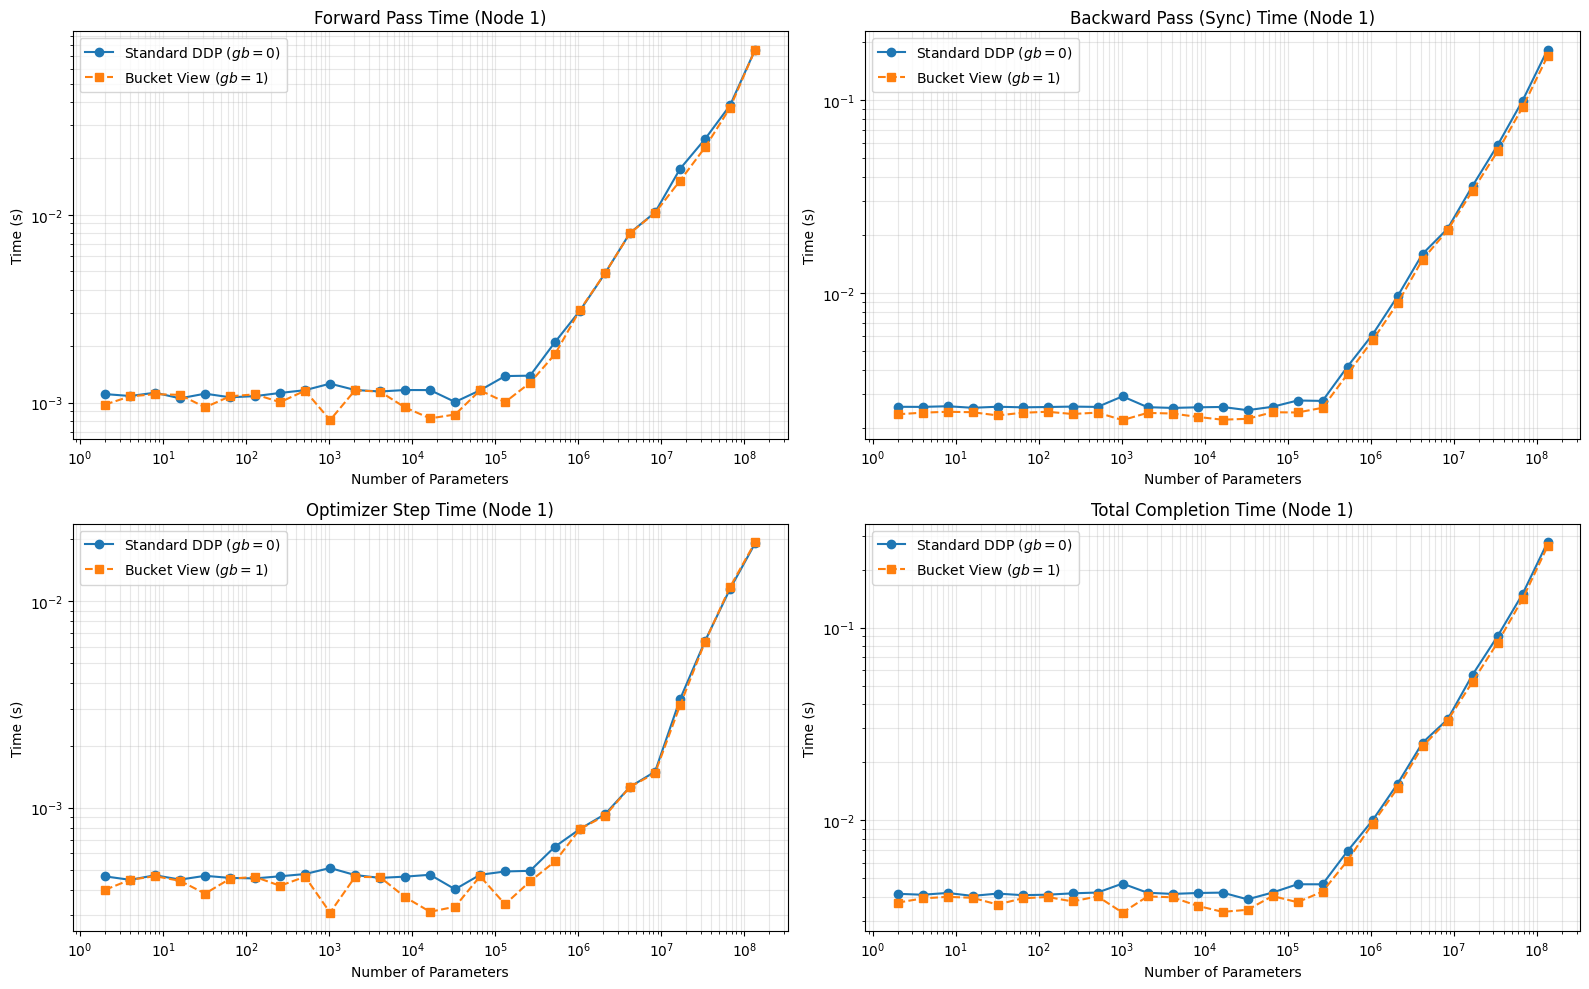

In [5]:
plot_node_performance_1(summary, 1)

# With GDR

In [8]:
all_data, summary = process_ddp_results(['./data/20260216_014521/'])
summary.head()

,node_id,num_params,grad_bucket,fwd_time,bwd_time,opt_time,total_time
0,1,1024,0,0.001068,0.002542,0.000434,0.004043
1,1,1024,1,0.001153,0.002399,0.000466,0.004018
2,1,2048,0,0.001160,0.002571,0.000458,0.004190
3,1,2048,1,0.001150,0.002392,0.000455,0.003996
4,1,4096,0,0.001161,0.002581,0.000472,0.004214


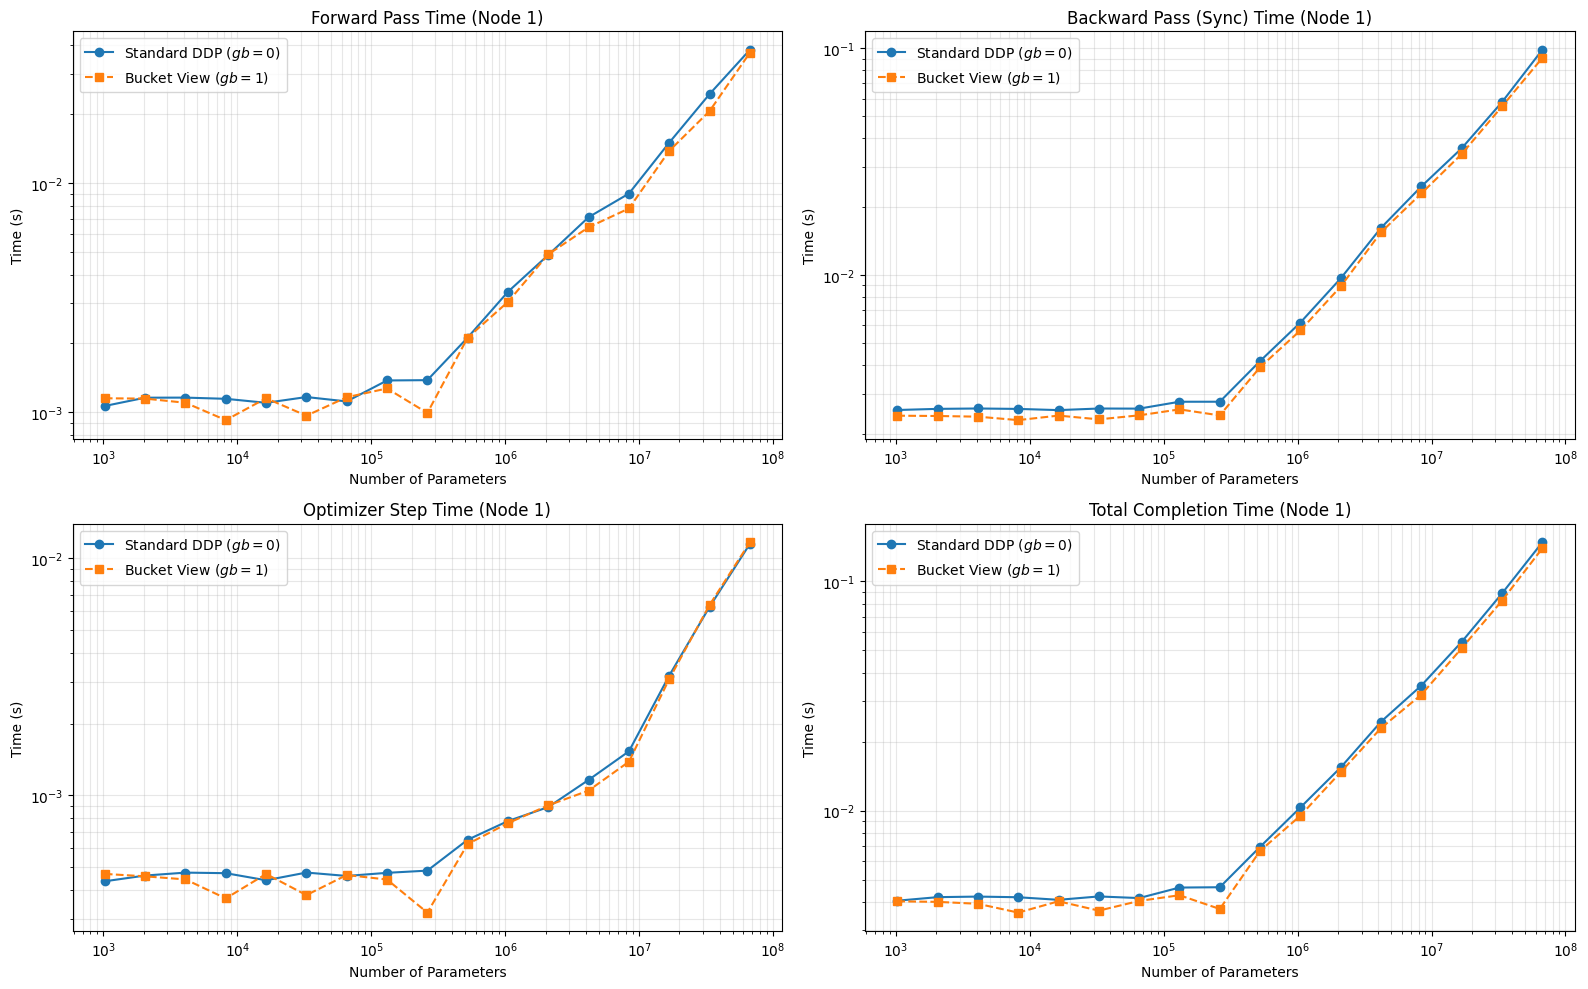

In [9]:
plot_node_performance_1(summary, 1)

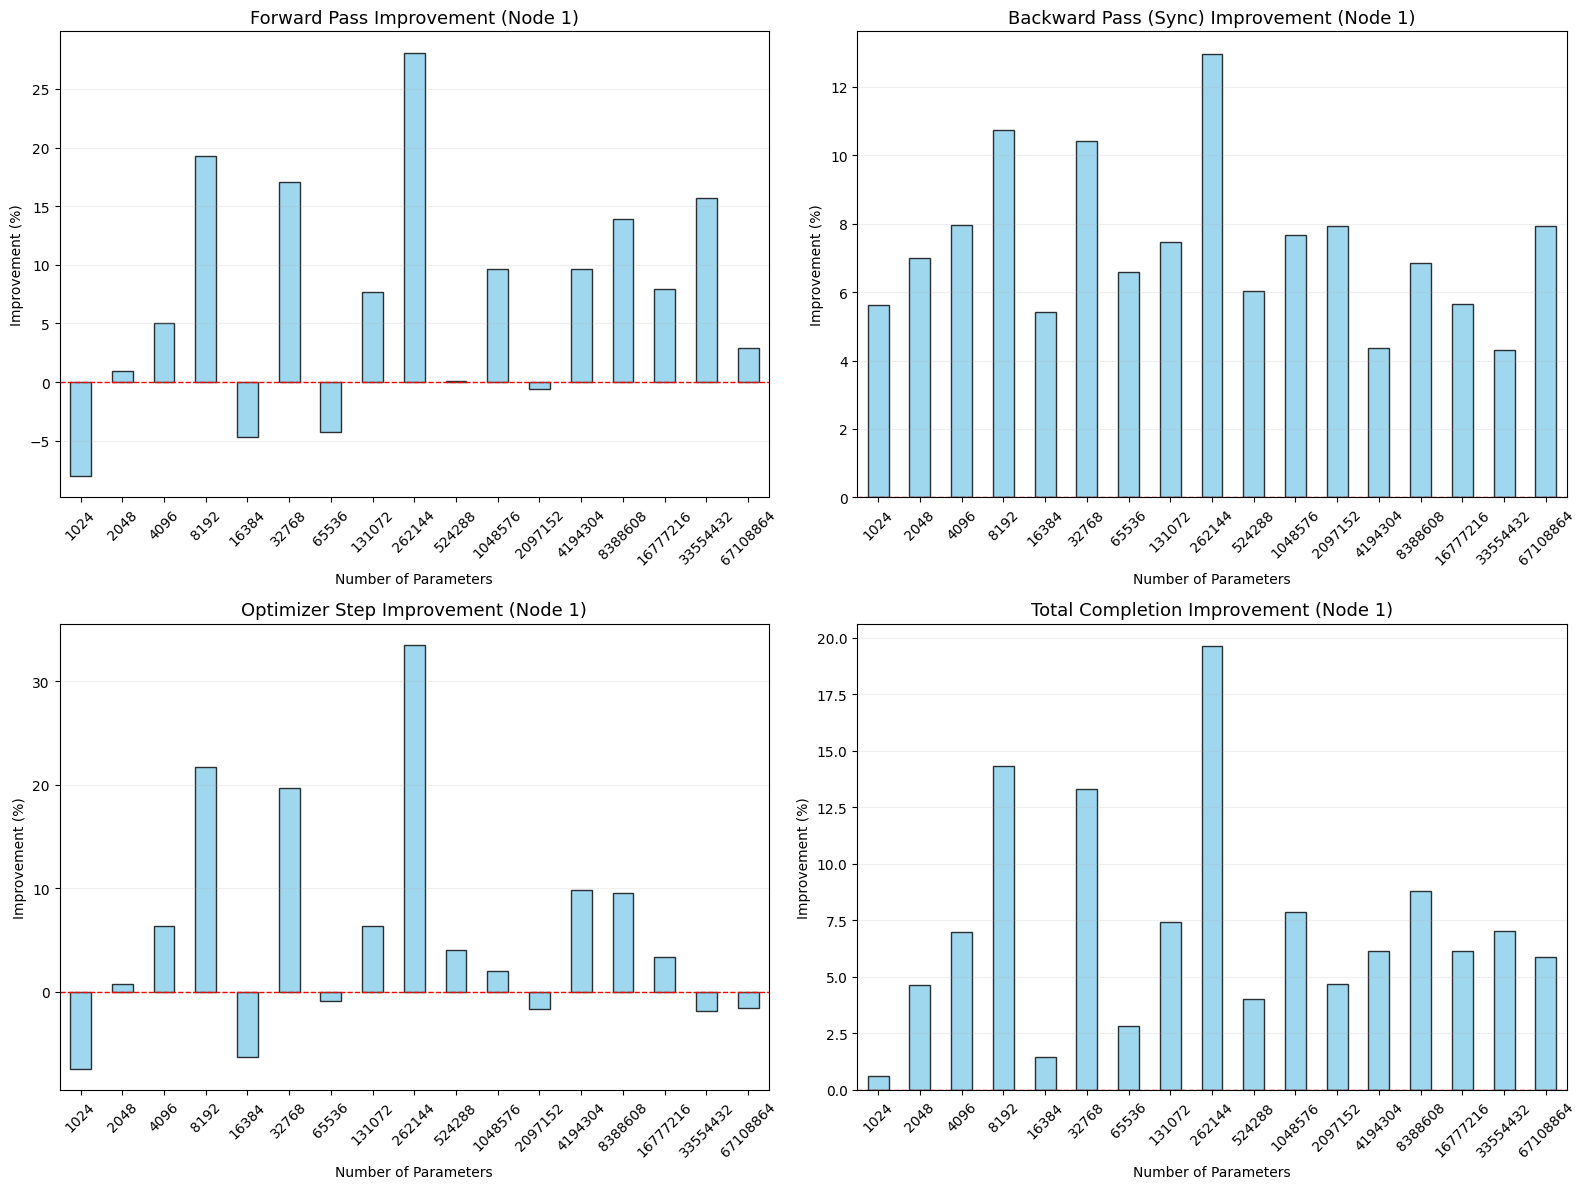

In [13]:
plot_improvement_percentage(summary, 1)

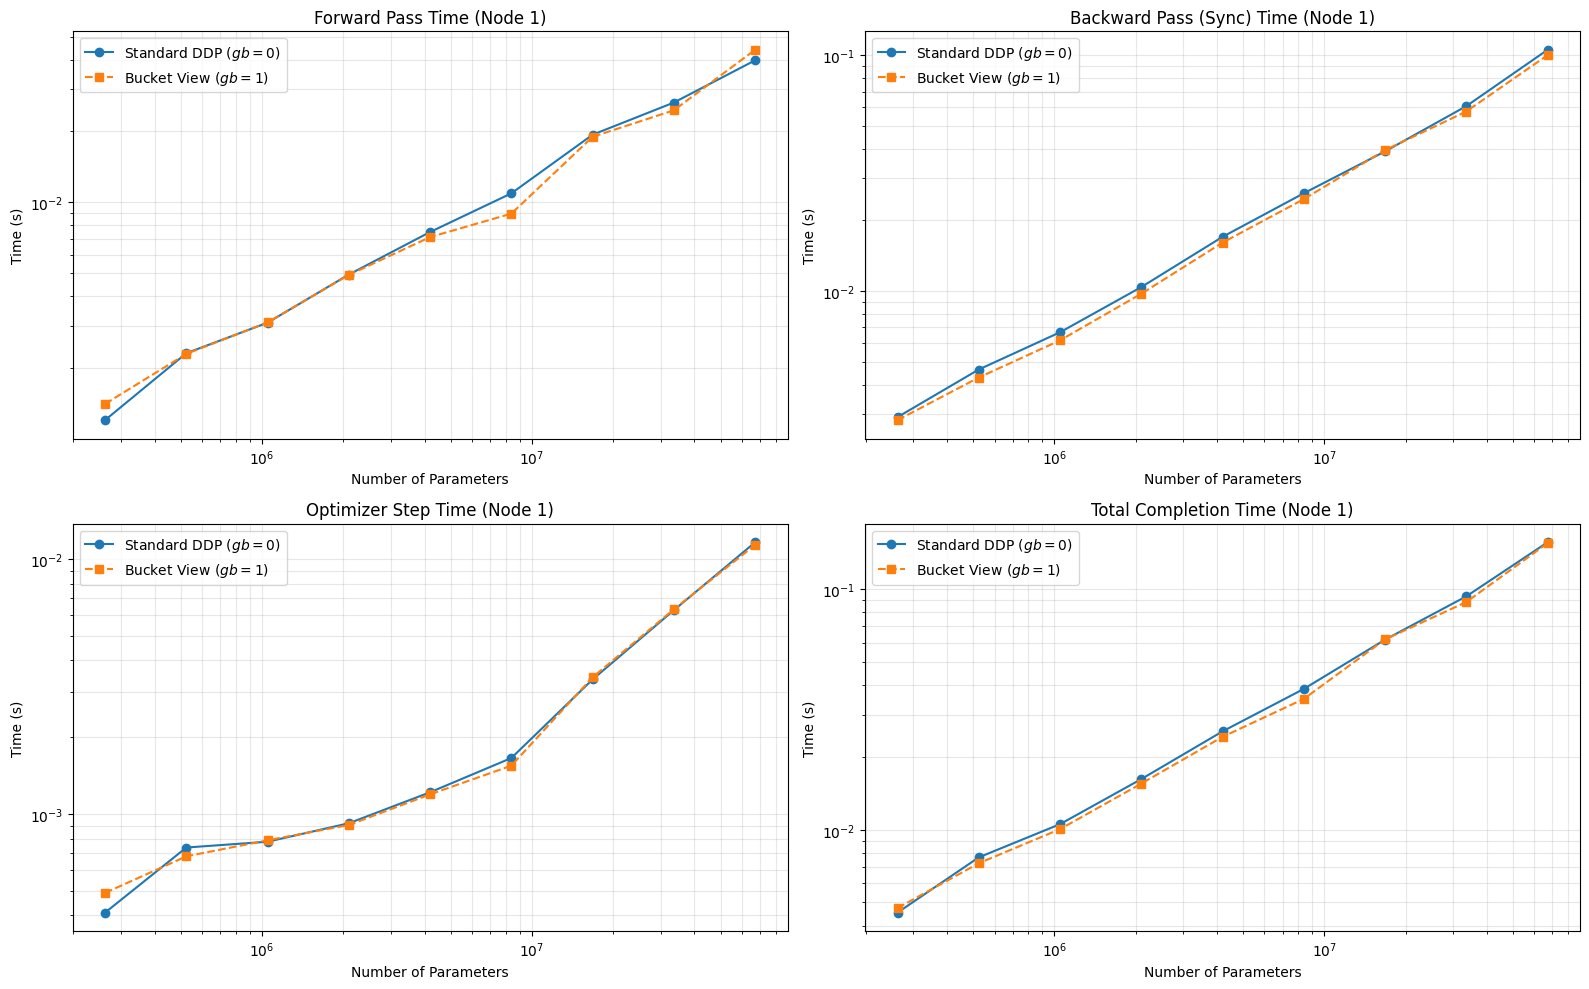

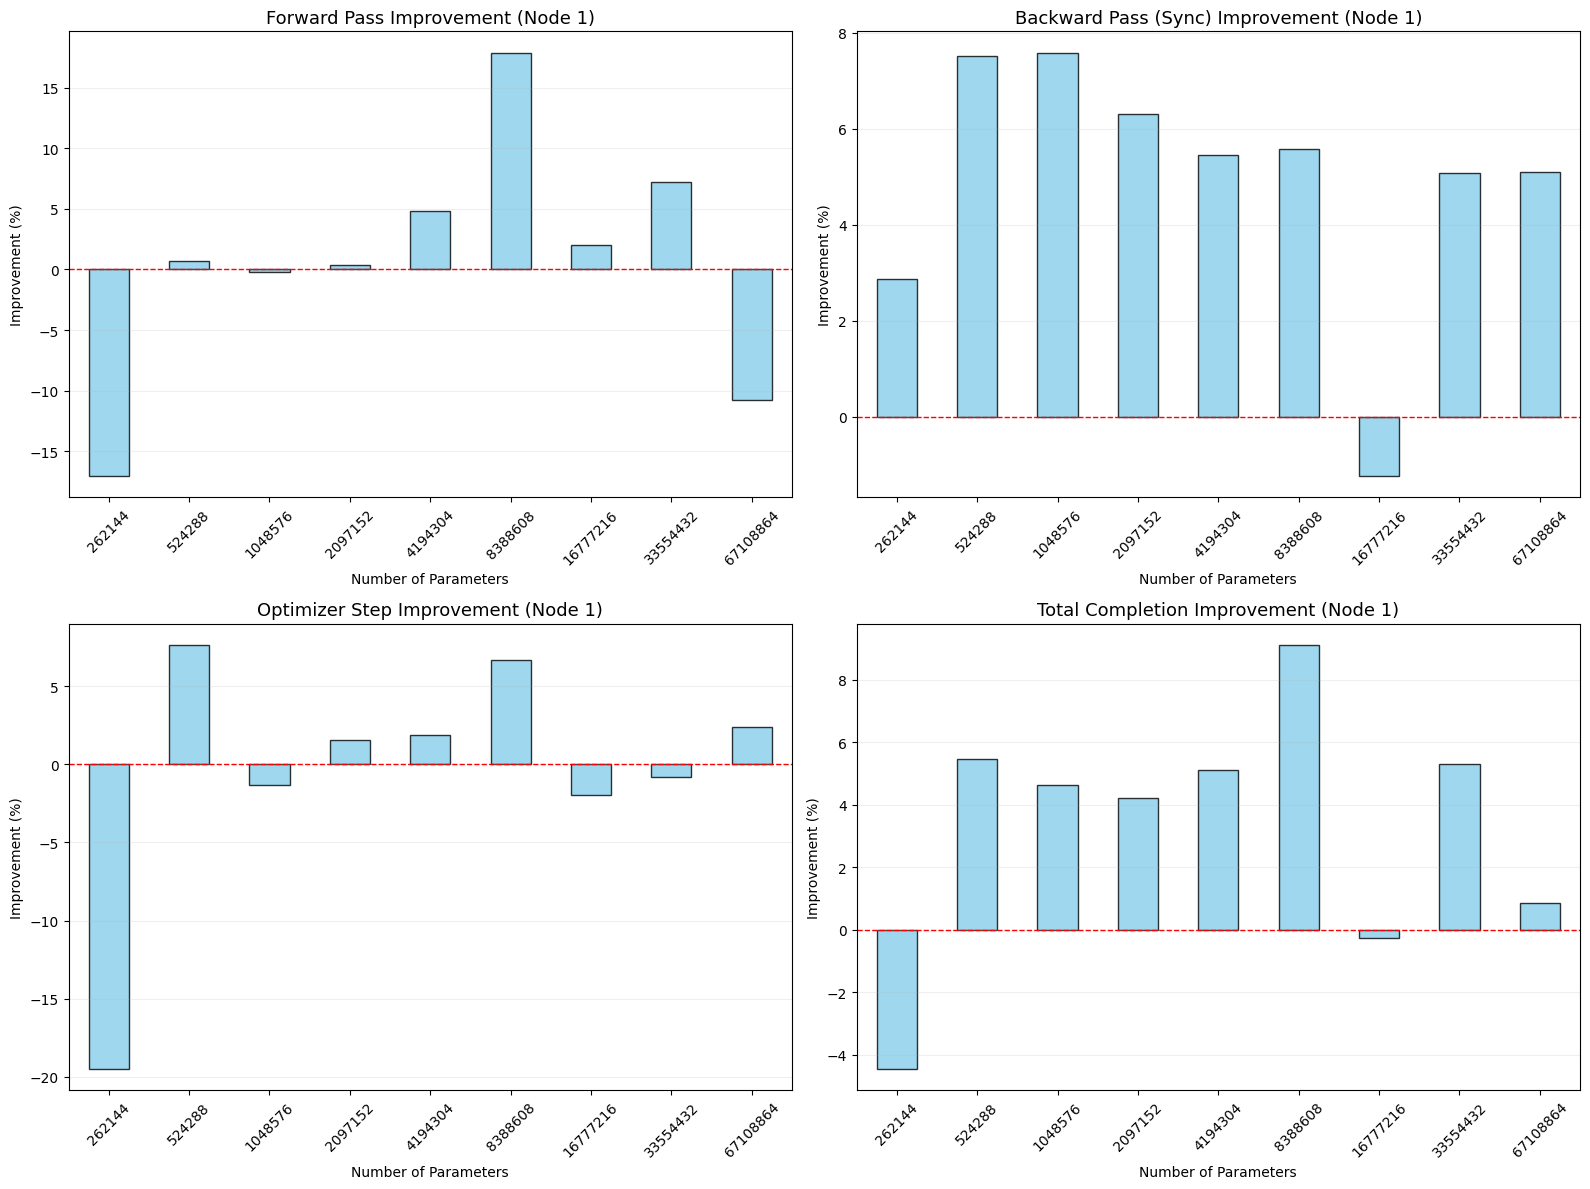

In [16]:
all_data, summary = process_ddp_results(['./data/20260216_041416/'])
plot_node_performance_1(summary, 1)
plot_improvement_percentage(summary, 1)

In [5]:
all_data, summary = process_ddp_results(['./data/20260216_143615/'])
summary.head()

,node_id,num_params,grad_bucket,fwd_time,bwd_time,opt_time,total_time
0,1,262144,0,0.001507,0.003149,0.000529,0.005185
1,1,262144,1,0.001293,0.002595,0.000459,0.004347
2,1,524288,0,0.002118,0.004219,0.000653,0.006990
3,1,524288,1,0.002121,0.003943,0.000625,0.006689
4,1,1048576,0,0.003103,0.006190,0.000775,0.010069


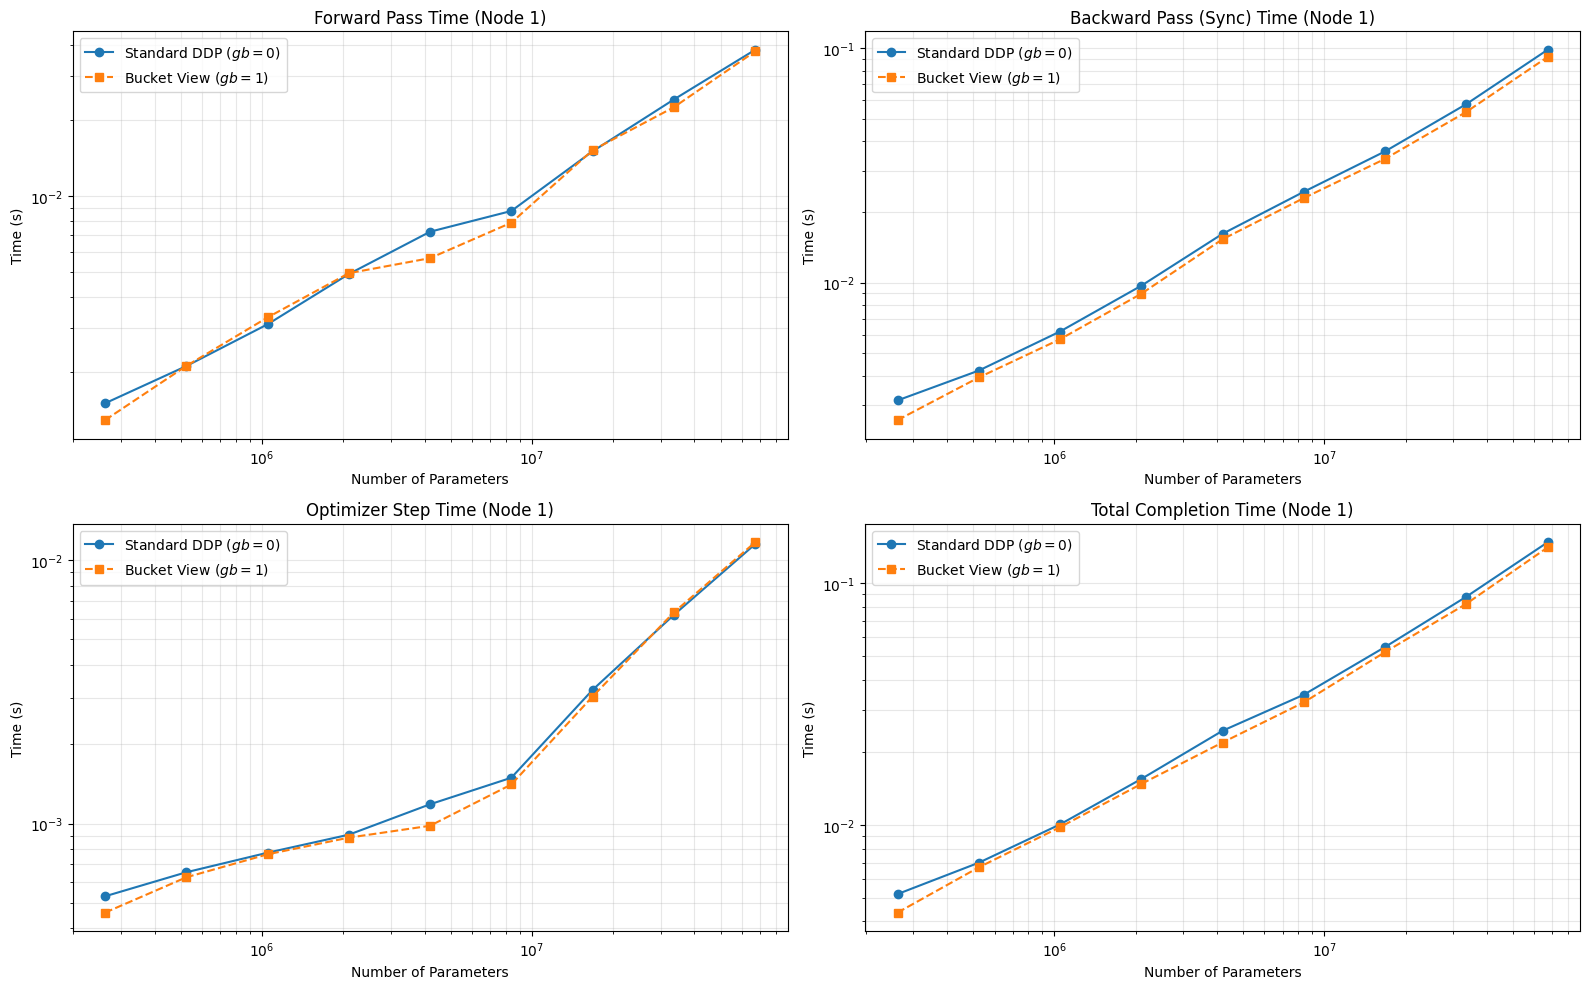

In [6]:
plot_node_performance_1(summary, 1)